In [1]:


import os

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from azure.cognitiveservices.vision.customvision.prediction import CustomVisionPredictionClient
from azure.cognitiveservices.vision.customvision.training import CustomVisionTrainingClient
from dotenv import load_dotenv
from msrest.authentication import ApiKeyCredentials

In [2]:
load_dotenv("../.env")

BAGGAGE_ROOT_PATH = '../material_preparation_step/baggage'

LIGHTER_DETECTOR_PROJECT_ID = os.environ["LIGHTER_DETECTOR_PROJECT_ID"]
LIGHTER_DETECTOR_TRAINING_ENDPOINT = os.environ["LIGHTER_DETECTOR_TRAINING_ENDPOINT"]
LIGHTER_DETECTOR_TRAINING_KEY = os.environ["LIGHTER_DETECTOR_TRAINING_KEY"]
LIGHTER_DETECTOR_TRAINING_RESOURCE_ID = os.environ["LIGHTER_DETECTOR_TRAINING_RESOURCE_ID"]

LIGHTER_DETECTOR_PREDICTION_ENDPOINT = os.environ["LIGHTER_DETECTOR_PREDICTION_ENDPOINT"]
LIGHTER_DETECTOR_PREDICTION_KEY = os.environ["LIGHTER_DETECTOR_PREDICTION_KEY"]
LIGHTER_DETECTOR_PREDICTION_RESOURCE_ID = os.environ["LIGHTER_DETECTOR_PREDICTION_RESOURCE_ID"]

In [4]:
training_credentials = ApiKeyCredentials(in_headers={"Training-key": LIGHTER_DETECTOR_TRAINING_KEY})
trainer = CustomVisionTrainingClient(LIGHTER_DETECTOR_TRAINING_ENDPOINT, training_credentials)

In [5]:
iteration_list = trainer.get_iterations(LIGHTER_DETECTOR_PROJECT_ID)
model_perf = trainer.get_iteration_performance(LIGHTER_DETECTOR_PROJECT_ID, iteration_list[0].id)

In [6]:
model_perf.as_dict()

{'per_tag_performance': [{'id': '871ee07c-643c-4621-b3f0-86f3161572d7',
   'name': 'lighter',
   'precision': 0.64285713,
   'precision_std_deviation': 0.0,
   'recall': 0.9,
   'recall_std_deviation': 0.0,
   'average_precision': 0.8521032}],
 'precision': 0.64285713,
 'precision_std_deviation': 0.0,
 'recall': 0.9,
 'recall_std_deviation': 0.0,
 'average_precision': 0.8521032}

In [7]:
publish_iteration_name = "boarding-kiosk-lighter-detector"

In [8]:
trainer.publish_iteration(LIGHTER_DETECTOR_PROJECT_ID, iteration_list[0].id, publish_iteration_name, LIGHTER_DETECTOR_PREDICTION_RESOURCE_ID)
print ("Done!")

Done!


In [9]:
prediction_credentials = ApiKeyCredentials(in_headers={"Prediction-key": LIGHTER_DETECTOR_PREDICTION_KEY})
predictor = CustomVisionPredictionClient(endpoint=LIGHTER_DETECTOR_PREDICTION_ENDPOINT, credentials=prediction_credentials)

In [10]:
def detect_lighter(image_name):
    local_image_path = os.path.join(BAGGAGE_ROOT_PATH, image_name)

    with open(local_image_path, "rb") as image_contents:
        results = predictor.detect_image(
            LIGHTER_DETECTOR_PROJECT_ID,
            publish_iteration_name,
            image_contents.read()
        )

    img = Image.open(local_image_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    for prediction in results.predictions:
        if prediction.probability > 0.75:
            bbox = prediction.bounding_box
            left = bbox.left * img.width
            top = bbox.top * img.height
            right = (bbox.left + bbox.width) * img.width
            bottom = (bbox.top + bbox.height) * img.height

            draw.rectangle([left, top, right, bottom], outline="red", width=4)
            label = f"{prediction.tag_name}: {prediction.probability * 100:.2f}%"
            draw.text((left, max(0, top - 20)), label, fill="red")

    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predictions for {image_name}")
    plt.show()

Detected lighters in baggage-avkash.jpg


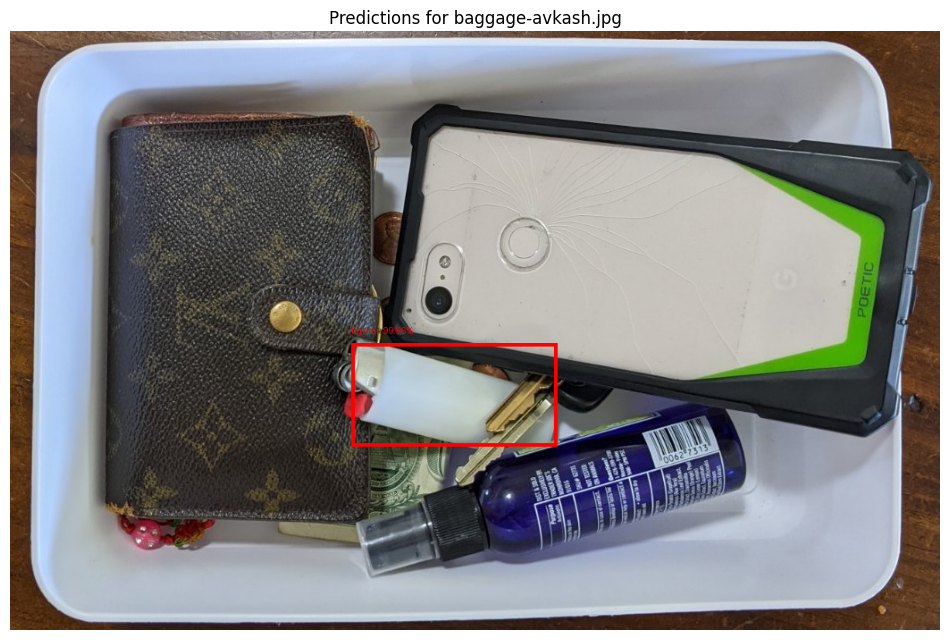

Detected lighters in baggage-james.jpg


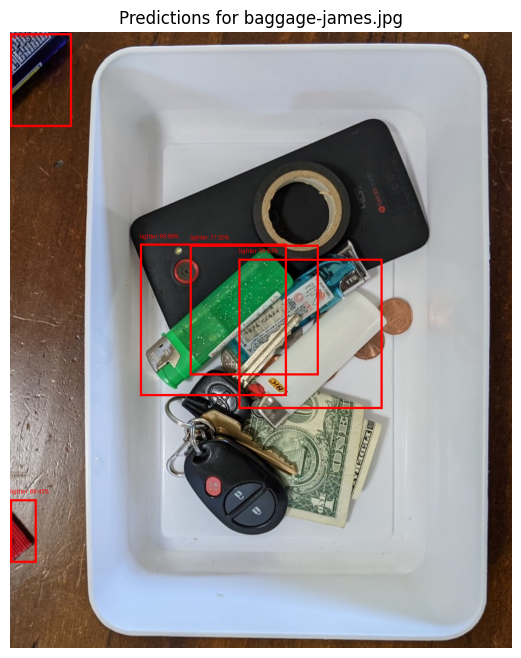

Detected lighters in baggage-libby.jpg


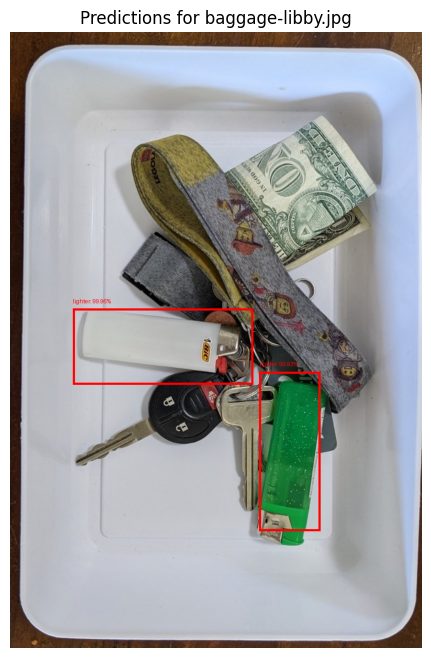

Detected lighters in baggage-radha.jpg


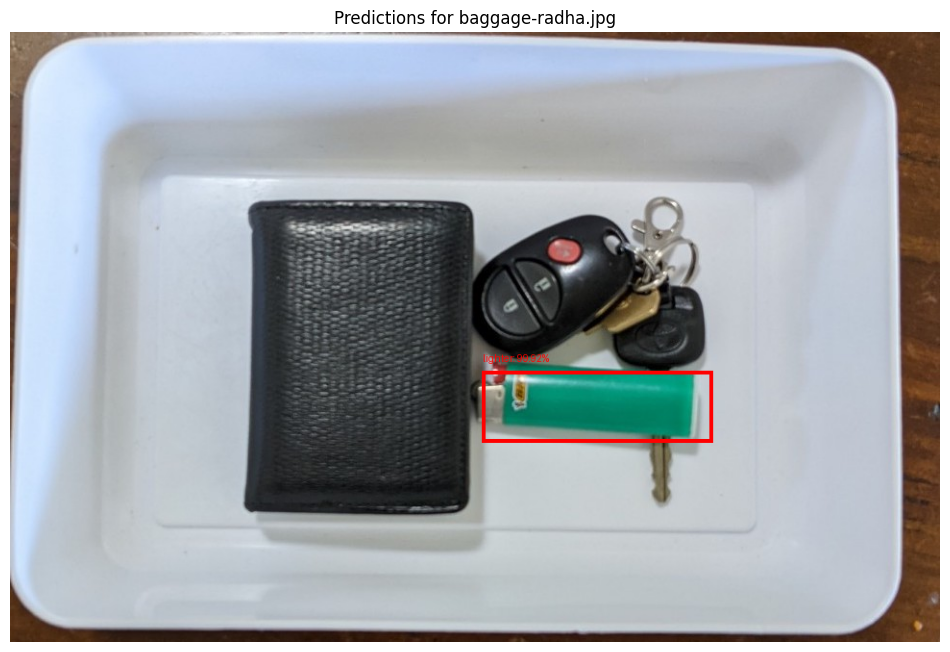

Detected lighters in baggage-webb.jpg


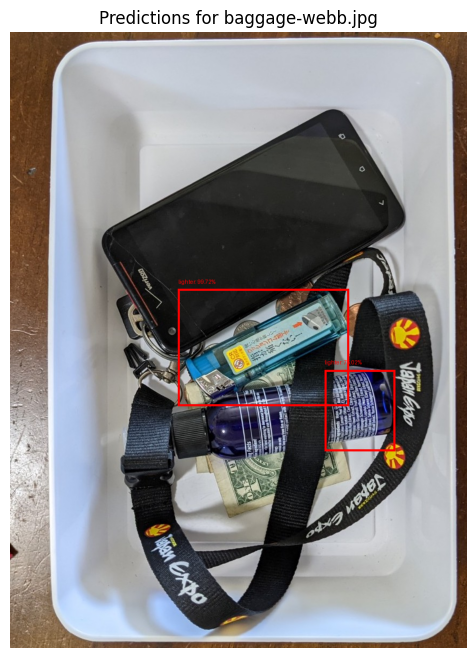

In [11]:
test_images = ["baggage-avkash.jpg", "baggage-james.jpg", "baggage-libby.jpg", "baggage-radha.jpg", "baggage-webb.jpg"]
for test_image in test_images:
    print(f"Detected lighters in {test_image}")
    detect_lighter(test_image)